#### Data types and image size
- Array's data type controls range of possible intensities

In [7]:
import imageio
im = imageio.imread('hand.jpg')

im.dtype
im.size

C:\Users\USER\AppData\Local\Temp\ipykernel_24200\2015435197.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('hand.jpg')


153600

In [9]:
import numpy as np
im_int64 = im.astype(np.uint64)
im_int64.size

153600

#### Histograms
- Histograms: count number of pixels at each `intensity value`.
- implemented in `scipy.ndimage`
    - higher-dimensional arrays
    - masked data
- Advanced techniques and functionality in `scikit-image`

In [11]:
import scipy.ndimage as ndi
hist = ndi.histogram(im, min=0, max=255, bins=256)

hist.shape

(256,)

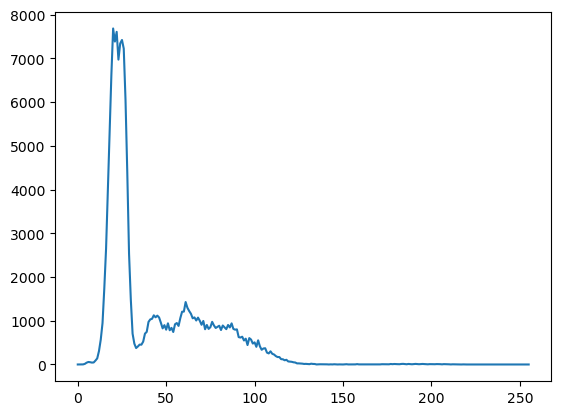

In [13]:
import matplotlib.pyplot as plt
plt.plot(hist)
plt.show()

#### Equalization
- Distributions often skewed toward low intensities (background values).
- Equalization: redistribute values to optimize full intensity range.
- Cummulative distribution function: (CDF) shows proportion of pixels in range


In [14]:
import scipy.ndimage as ndi
hist = ndi.histogram(im, min=0, max=255, bins=256)
cdf = hist.cumsum() / hist.sum()
cdf.shape

(256,)

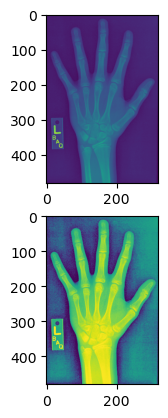

In [17]:
im_equalized = cdf[im] * 255
fig, axes = plt.subplots(2, 1)
axes[0].imshow(im)
axes[1].imshow(im_equalized)
plt.show()

In [18]:
def format_and_render_plot():
    '''Custom function to simplify common formatting operations for exercises. Operations include: \n    1. Turning off axis grids.\n    2. Calling `plt.tight_layout` to improve subplot spacing.\n    3. Calling `plt.show()` to render plot.'''  
    fig = plt.gcf()    
    fig.axes[0].axis('off')   
    plt.tight_layout()
    plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_24200\3444492677.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('hand.jpg')


Data type: uint8
Min. value: 3
Max value: 224


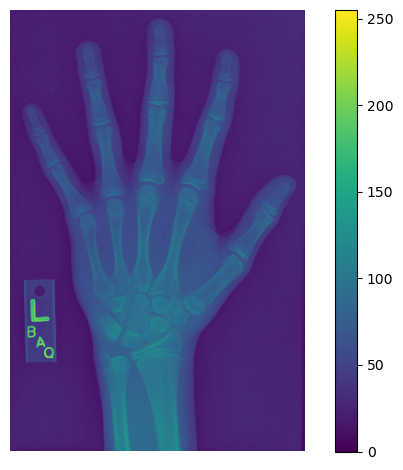

In [19]:
# Load the hand radiograph
im = imageio.imread('hand.jpg')
print('Data type:', im.dtype)
print('Min. value:', im.min())
print('Max value:', im.max())

# Plot the grayscale image
plt.imshow(im, vmin=0, vmax=255)
plt.colorbar()
format_and_render_plot()

#### Histogram


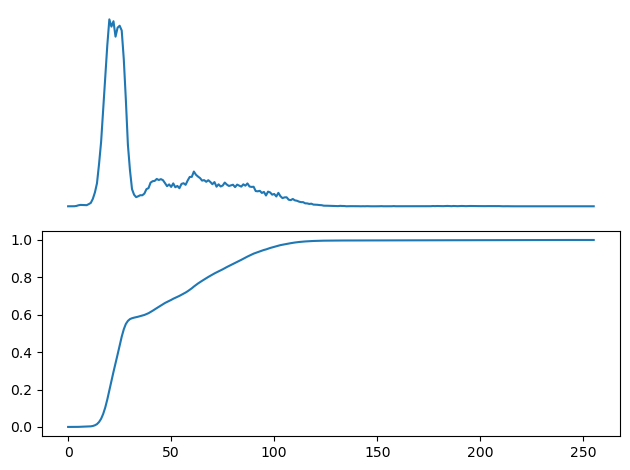

In [20]:
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi 

# Create a histogram, binned at each possible value
hist = ndi.histogram(im,min=0, max=255, bins=256)

# Create a cumulative distribution function
cdf = hist.cumsum() / hist.sum()

# Plot the histogram and CDF
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(hist, label='Histogram')
axes[1].plot(cdf, label='CDF')
format_and_render_plot()

#### Masks
- A mask is a Boolean array serves as screen to remove undesirable pixes.
- A mask serves as a screen to remove undesirable pixels
- It must retain the same dimensions as the original image so that the two can be ovelaid

#### Creating masks
Logical operations result in `True` / `False` at each pixel

In [21]:
mat = np.array([[1, 2, 3],
                [4, 5, 6],
                [7, 8, 9]])

mat > 5

array([[False, False, False],
       [False, False,  True],
       [ True,  True,  True]])

In [23]:
# Creating masks
hist = ndi.histogram(im, 0, 255, 256)

In [24]:
mask1 = im > 32

In [25]:
mask2 = im > 64

In [26]:
mask3 = mask1 & ~mask2

#### Applying masks
`np.where(condition, x, y)` control wwhat data passes through the mask.

In [27]:
import numpy as np
im_bone = np.where(im > 64, im, 0)

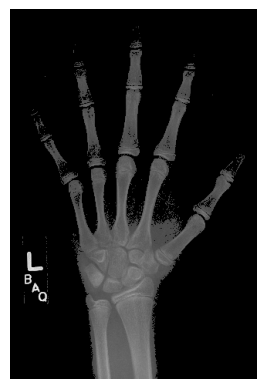

In [28]:
plt.imshow(im_bone, cmap='gray')
plt.axis('off')
plt.show()

#### Tuning masks

In [29]:
n = np.where(im > 64, 1, 0)

In [30]:
ndi.binary_dilation(n, iterations=5)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [32]:
ndi.binary_erosion(n, iterations=5)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

#### Exercise: 

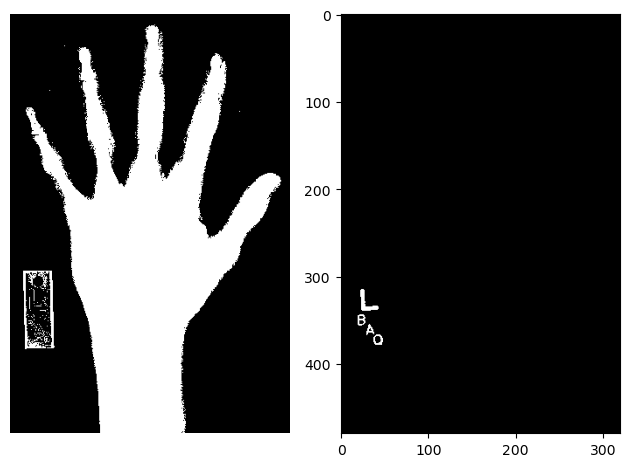

In [35]:
# Create skin and bone masks
mask_bone = im >= 145
mask_skin = (im >= 45) & (im < 145)

# Plot the skin (0) and bone (1) masks
fig, axes = plt.subplots(1,2)
axes[0].imshow(mask_skin, cmap='gray')
axes[1].imshow(mask_bone, cmap='gray')
format_and_render_plot()

#### Apply a mask

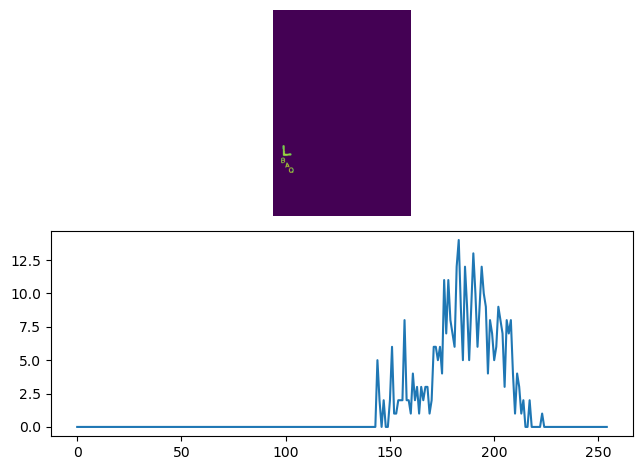

In [36]:
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi

# Screen out non-bone pixels from "im"
mask_bone = im >= 145
im_bone = np.where(mask_bone, im, 0)

# Get the histogram of bone intensities
hist = ndi.histogram( im_bone,min=1, max=255, bins=255)

# Plot masked image and histogram
fig, axes = plt.subplots(2,1)
axes[0].imshow(im_bone)
axes[1].plot(hist)
format_and_render_plot()

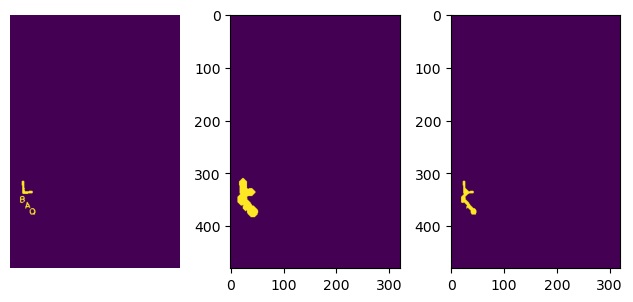

In [38]:
# Create and tune bone mask
mask_bone = im_bone >= 145
mask_dilate = ndi.binary_dilation(mask_bone, iterations=5)
mask_closed = ndi.binary_closing(mask_bone, iterations=5)

# Plot masked images
fig, axes = plt.subplots(1,3)
axes[0].imshow(mask_bone)
axes[1].imshow(mask_dilate)
axes[2].imshow(mask_closed)
format_and_render_plot()

### Filters
- Convolutional filter

#### Image convolution

In [40]:
import imageio
import scipy.ndimage as ndi

im = imageio.imread('hand.jpg')
weights = [[.11, .11, .11],
           [.11, .12, .11],
           [.11, .11, .11]]

im_filt = ndi.convolve(im, weights)

C:\Users\USER\AppData\Local\Temp\ipykernel_24200\269183408.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('hand.jpg')


TypeError: imshow() missing 1 required positional argument: 'X'

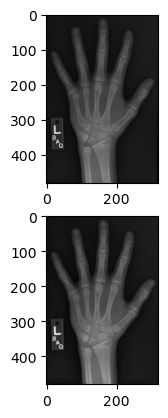

In [47]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1)
axes[0].imshow(im, cmap='gray')
axes[1].imshow(im_filt, cmap='gray')
plt.imshow()


#### Filtering functions
`scipy.ndimage.filters`
includes:
- `median_filter()`
- `uniform_filter()`
- `maximum_filter()`
- `percentile_filter()`

In [52]:
m_filt = ndi.median_filter(im, size=10)

TypeError: imshow() missing 1 required positional argument: 'X'

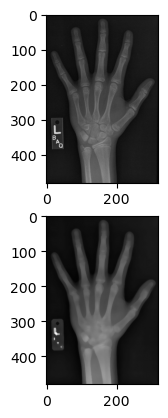

In [53]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1)
axes[0].imshow(im, cmap='gray')
axes[1].imshow(m_filt, cmap='gray')
plt.imshow()


#### Guassian filtering
Gaussian distribution in 1 dimension.
Gaussina distribution in 2 dimensions

In [54]:
g_filt = ndi.gaussian_filter(im, sigma=5)

TypeError: imshow() missing 1 required positional argument: 'X'

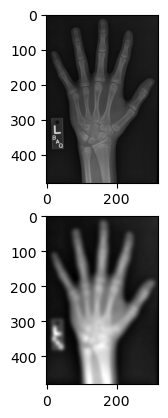

In [55]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1)
axes[0].imshow(im, cmap='gray')
axes[1].imshow(g_filt, cmap='gray')
plt.imshow()


#### Exercise:

In [56]:
# Set filter weights
weights = [[0.11, 0.11, 0.11],
           [0.11, 0.11, 0.11], 
           [0.11, 0.11, 0.11]]

In [ ]:
# Set filter weights
weights = [[0.11, 0.11, 0.11],
           [0.11, 0.11, 0.11], 
           [0.11, 0.11, 0.11]]

# Convolve the image with the filter
im_filt = ndi.convolve(im, weights)

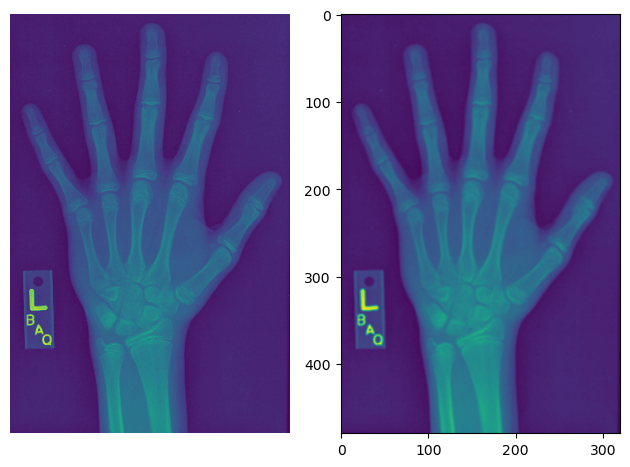

In [57]:
# Set filter weights
weights = [[0.11, 0.11, 0.11],
           [0.11, 0.11, 0.11], 
           [0.11, 0.11, 0.11]]

# Convolve the image with the filter
im_filt = ndi.convolve(im, weights)

# Plot the images
fig, axes = plt.subplots(1,2)
axes[0].imshow(im)
axes[1].imshow(im_filt)
format_and_render_plot()

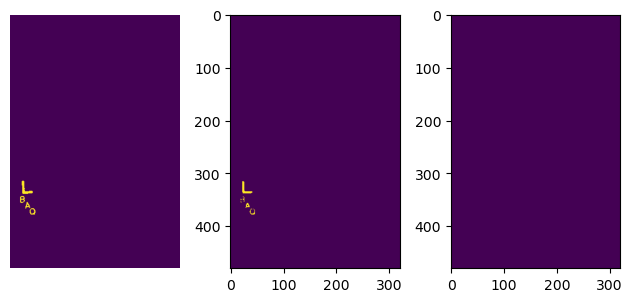

In [58]:
# Smooth "im" with Gaussian filters
im_s1 = ndi.gaussian_filter(im, sigma=1)
im_s3 = ndi.gaussian_filter(im, sigma=3)

# Draw bone masks of each image
fig, axes = plt.subplots(1,3)
axes[0].imshow(im >= 145)
axes[1].imshow(im_s1 >= 145)
axes[2].imshow(im_s3 >= 145)
format_and_render_plot()

#### Feature detection

C:\Users\USER\AppData\Local\Temp\ipykernel_24200\3651576877.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('hand.jpg')


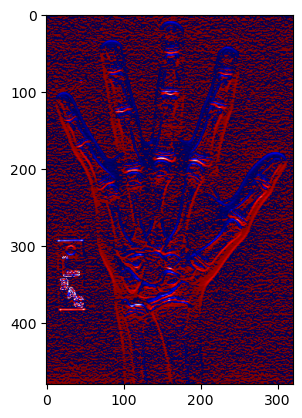

In [59]:
im = imageio.imread('hand.jpg')
weights = [[+1, +1, +1],
           [ 0,  0,  0], 
           [-1, -1, -1]]

edges = ndi.convolve(im, weights)
plt.imshow(edges, cmap='seismic')

#### Sobel filters

In [60]:
ndi.sobel(im, axis=0)

array([[  5,   4, 255, ..., 237, 235, 238],
       [ 12,   7, 255, ..., 237, 234, 230],
       [  4,   3,   3, ..., 255, 255, 251],
       ...,
       [238, 242, 243, ...,   2, 255, 250],
       [ 10, 245, 241, ..., 252, 246, 234],
       [ 27,   4, 253, ..., 250, 248, 243]], dtype=uint8)

In [61]:
ndi.sobel(im, axis=1)

array([[  1,  10,   1, ...,  13,   9,   2],
       [  2,   3, 251, ...,   9,   8,   2],
       [  2, 253, 249, ...,   9,   5, 253],
       ...,
       [  4, 252, 253, ..., 216,  27,  32],
       [248, 247, 255, ..., 216,  18,  24],
       [221, 230,   5, ..., 216,  10,  15]], dtype=uint8)

#### Sobel filter magnitude
Combine horizontal and vertical edge data by calculation odistance: z = (x^2 + y^2)^(1/2)

In [62]:
edges0 = ndi.sobel(im, axis=0)
edges1 = ndi.sobel(im, axis=1)

edges=np.sqrt(np.square(edges0) + np.square(edges1))

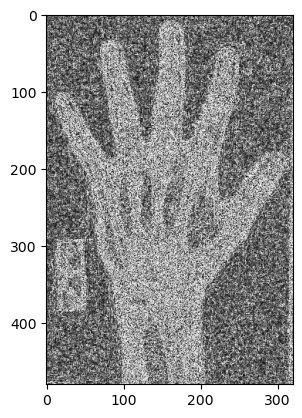

In [63]:
plt.imshow(edges, cmap='gray')

#### Detect edges (1)

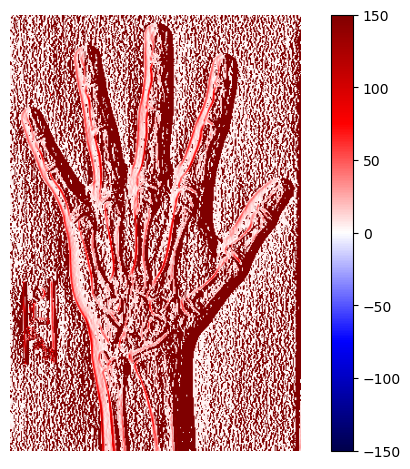

In [64]:
# Set weights to detect vertical edges
weights = [[1, 0, -1], [1, 0, -1], [1, 0, -1]]

# Convolve "im" with filter weights
edges = ndi.convolve(im, weights)

# Draw the image in color
plt.imshow(edges, cmap='seismic', vmin=-150, vmax=150)
plt.colorbar()
format_and_render_plot()

#### Detect edges

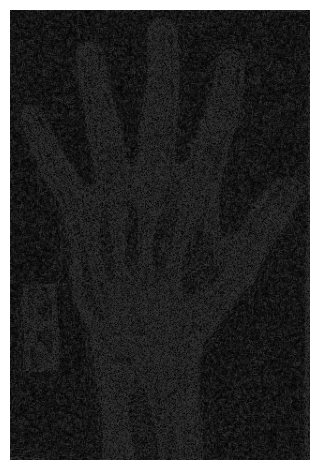

In [65]:
# Apply Sobel filter along both axes
sobel_ax0 = ndi.sobel(im, axis=0)
sobel_ax1 = ndi.sobel(im, axis=1)

# Calculate edge magnitude 
edges = np.sqrt(np.square(sobel_ax0) + np.square(sobel_ax1))

# Plot edge magnitude
plt.imshow(edges, cmap='gray', vmax=75)
format_and_render_plot()

##### Objects and labels
#### Segmentation splits an image into parts
#### Labeling image components

In [11]:
import scipy.ndimage as ndi
import imageio
im = imageio.imread('SCD2001_000/SCD2001_MR_201.dcm')
filt=ndi.gaussian_filter(im, sigma=2)
mask = filt > 150
labels, nlabels = ndi.label(mask)

C:\Users\USER\AppData\Local\Temp\ipykernel_19804\2194496679.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('SCD2001_000/SCD2001_MR_201.dcm')


In [12]:
nlabels

4

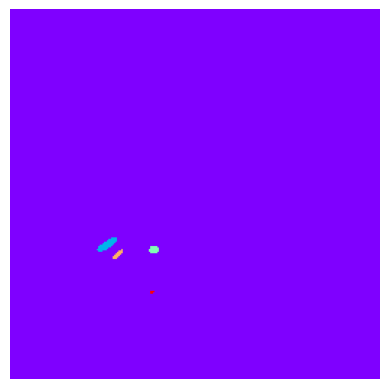

In [13]:
import matplotlib.pyplot as plt
plt.imshow(labels, cmap='rainbow')
plt.axis('off')
plt.show()

#### Label selection
- Select a single label within

In [15]:
import numpy as np
np.where(labels ==1, im, 0)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int16)

- Select many labels within

In [18]:
np.where(labels < 3, im, 0)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int16)

#### Object extraction
- Bounding box: range of pixels that completely encloses an object
- `ndi.find_objects()` returns a list of bounding box coordinates

#### Object extraction

In [19]:
labels, nlabels = ndi.label(mask)
boxes = ndi.find_objects(labels)
boxes[0]

(slice(158, 168, None), slice(60, 74, None))

#### Exercise:
- Segment the heart

In [20]:
# Smooth intensity values
im_filt = ndi.median_filter(im, size=3)

# Select high-intensity pixels
mask_start = np.where(im_filt > 60, 1, 0)
mask = ndi.binary_closing(mask_start)

# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
print('Num. Labels:', nlabels)

Num. Labels: 22


In [22]:
def format_and_render_plot():
    '''Custom function to simplify common formatting operations for exercises. Operations include: \n    1. Turning off axis grids.\n    2. Calling `plt.tight_layout` to improve subplot spacing.\n    3. Calling `plt.show()` to render plot.'''  
    fig = plt.gcf()    
    fig.axes[0].axis('off')   
    plt.tight_layout()
    plt.show()

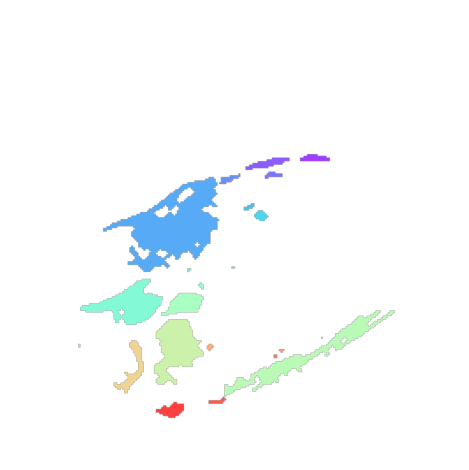

In [24]:
# Create a `labels` overlay
overlay = np.where(labels > 0, labels, np.nan)

# Use imshow to plot the overlay
plt.imshow(overlay, cmap='rainbow', alpha=0.75)
format_and_render_plot()